# Model Evaluation and Refinement


<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_3%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_3%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

This dataset was hosted on IBM Cloud object. Click <a href="https://cocl.us/DA101EN_object_storage">HERE</a> for free storage.


In [1]:
import pandas as pd
import numpy as np

# Import clean data 
path = 'module_5_auto.csv'
df = pd.read_csv(path)
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,0,0,0,3,122,alfa-romero,std,two,convertible,rwd,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,1,1,1,3,122,alfa-romero,std,two,convertible,rwd,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,2,2,2,1,122,alfa-romero,std,two,hatchback,rwd,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,3,3,3,2,164,audi,std,four,sedan,fwd,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,4,4,4,2,164,audi,std,four,sedan,4wd,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [2]:
df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'symboling',
       'normalized-losses', 'make', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='object')

In [3]:
df = df.drop(columns=["Unnamed: 0.2", "Unnamed: 0.1", "Unnamed: 0"])
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<h2>Functions for Plotting</h2>


In [4]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.show()
    plt.close()

In [5]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))
 
    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

## Part 1: Training and Testing

In [6]:
y_data = df['price']
x_data=df.drop('price',axis=1)

In [7]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])


number of test samples : 21
number of training samples: 180


The <b>test_size</b> parameter sets the proportion of data that is split into the testing set. In the above, the testing set is 10% of the total dataset. 


In [8]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size = 0.4, random_state = 0)

Let's import <b>LinearRegression</b> from the module <b>linear_model</b>.


In [9]:
from sklearn.linear_model import LinearRegression
lre=LinearRegression()
lre.fit(x_train[['horsepower']], y_train)

LinearRegression()

### 📈 **What is R² score?**

* R² (coefficient of determination) is a statistical measure of how well the regression predictions approximate the real data points.
* **Range**: `R²` ranges from negative infinity to 1:

  * `1` → perfect prediction
  * `0` → model predicts no better than the mean
  * `< 0` → model is worse than just predicting the mean

In [10]:
lre.score(x_test[['horsepower']], y_test)

0.3635875575078824

We can see the R^2 is much smaller using the test data compared to the training data.


In [11]:
lre.score(x_train[['horsepower']], y_train)

0.6619724197515103

In [12]:
lre.fit(x_train1[['horsepower']],y_train1)
lre.score(x_test1[['horsepower']],y_test1)

0.7139364665406973

## Cross-Validation Score


`cross_val_score` is a utility function in **scikit-learn** used for **evaluating a model using cross-validation**. Instead of evaluating your model on just one train/test split, cross-validation helps you assess how well the model generalizes to **unseen data** by testing it on multiple different splits.

---

### 🔁 What is Cross-Validation?

In **k-fold cross-validation**:

1. The data is split into **k subsets** (folds).
2. The model is trained on **k - 1 folds** and tested on the **remaining fold**.
3. This process is repeated **k times**, with each fold used as the test set once.
4. You get **k scores**, one for each fold.
5. These scores are typically **averaged** to produce a more stable estimate of model performance.

### 🔍 Parameters Explained

| Parameter          | Type                       | Default             | Description                                                                                                           |
| ------------------ | -------------------------- | ------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **`estimator`**    | estimator object           | *required*          | The model object to be evaluated (must implement `.fit()` and `.predict()` or `.predict_proba()` for classification). |
| **`X`**            | array-like or DataFrame    | *required*          | Feature data used for training and testing in cross-validation.                                                       |
| **`y`**            | array-like                 | `None`              | Target labels (for supervised learning). Not needed for unsupervised learning.                                        |
| **`scoring`**      | str, callable, or `None`   | `None`              | Scoring metric to evaluate model performance (e.g., `'accuracy'`, `'r2'`, `'neg_mean_squared_error'`).                |
| **`cv`**           | int, CV splitter, iterable | `5`                 | Number of folds or a cross-validation strategy object like `KFold`, `StratifiedKFold`.                                |
| **`n_jobs`**       | int                        | `None`              | Number of CPU cores to use. `-1` uses all available cores.                                                            |
| **`verbose`**      | int                        | `0`                 | Controls verbosity. Higher = more messages.                                                                           |
| **`fit_params`**   | dict                       | `None` (deprecated) | Parameters to pass to the `.fit()` method of the estimator. (Deprecated in newer versions of scikit-learn.)           |
| **`pre_dispatch`** | int or str                 | `'2*n_jobs'`        | Controls how many jobs are pre-dispatched when using parallelism.                                                     |
| **`error_score`**  | ‘raise’ or float           | `np.nan`            | Value to assign if an error occurs during model fitting. `'raise'` will raise the error.                              |




In [13]:
from sklearn.model_selection import cross_val_score

Rcross = cross_val_score(lre, x_data[['horsepower']], y_data, cv=4)
Rcross

array([0.7746232 , 0.51716687, 0.74785353, 0.04839605])

 We can calculate the average and standard deviation of our estimate:


In [14]:
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

The mean of the folds are 0.5220099150421194 and the standard deviation is 0.2911839444756025


In [15]:
-1 * cross_val_score(lre,x_data[['horsepower']], y_data,cv=4,scoring='neg_mean_squared_error')

array([20254142.84026704, 43745493.26505169, 12539630.34014931,
       17561927.72247589])

#### 📉 **Regression Metrics**

| Scoring Value                          | Description                             |
| -------------------------------------- | --------------------------------------- |
| `'r2'`                                 | R² (coefficient of determination)       |
| `'neg_mean_absolute_error'`            | Negative mean absolute error            |
| `'neg_mean_squared_error'`             | Negative mean squared error             |
| `'neg_root_mean_squared_error'`        | Negative root mean squared error        |
| `'neg_median_absolute_error'`          | Negative median absolute error          |
| `'neg_mean_squared_log_error'`         | Negative mean squared logarithmic error |
| `'neg_mean_poisson_deviance'`          | Negative mean Poisson deviance          |
| `'neg_mean_gamma_deviance'`            | Negative mean Gamma deviance            |
| `'neg_mean_absolute_percentage_error'` | Negative mean absolute percentage error |

> ⚠️ **Note on "neg\_" prefix**:
> Since scikit-learn assumes **higher scores are better**, all **loss functions** (like MSE) are returned as **negative values** so that lower error = higher score.


In [16]:
cross_val = cross_val_score(lre, x_data[['horsepower']],y_data,cv=2)
cross_val.mean()

0.5166761697127429

## 🔁 What is `cross_val_predict`?

**`cross_val_predict`** performs **cross-validation** like `cross_val_score`, but instead of returning **evaluation scores**, it returns the **predicted values** for each input data point — as if each prediction were made on a "held-out" fold.


### 📋 `cross_val_predict` Parameters Table

| Parameter          | Type                       | Default             | Description                                                                                                 |
| ------------------ | -------------------------- | ------------------- | ----------------------------------------------------------------------------------------------------------- |
| **`estimator`**    | estimator object           | *required*          | The model to fit and generate predictions (must implement `.fit()` and `.predict()` or `.predict_proba()`). |
| **`X`**            | array-like or DataFrame    | *required*          | Feature data used for training/testing in cross-validation.                                                 |
| **`y`**            | array-like                 | `None`              | Target labels (for supervised learning).                                                                    |
| **`groups`**       | array-like                 | `None`              | Group labels for the samples used while splitting the dataset (used for `GroupKFold`, etc.).                |
| **`cv`**           | int, CV splitter, iterable | `None` (default=5)  | Number of folds or a cross-validator like `KFold`, `StratifiedKFold`, etc.                                  |
| **`n_jobs`**       | int                        | `None`              | Number of CPU cores to use. `-1` uses all available cores.                                                  |
| **`verbose`**      | int                        | `0`                 | Controls verbosity.                                                                                         |
| **`fit_params`**   | dict                       | `None` (deprecated) | Parameters to pass to the model’s `.fit()` method.                                                          |
| **`pre_dispatch`** | int or str                 | `'2*n_jobs'`        | Controls how many jobs are dispatched during parallelism.                                                   |
| **`method`**       | str                        | `'predict'`         | Name of the prediction method: `'predict'`, `'predict_proba'`, `'decision_function'`, or `'transform'`.     |

---

## 🔄 What it Returns

```python
predictions = cross_val_predict(estimator, X, y, cv=5)
```

* Returns: **An array of predictions**, one per row in `X`.
* These are **cross-validated predictions**, meaning each value is predicted on a fold that did **not** include that sample during training.


In [17]:
from sklearn.model_selection import cross_val_predict

yhat = cross_val_predict(lre,x_data[['horsepower']], y_data,cv=4)
yhat[:5]

array([14141.63807508, 14141.63807508, 20814.29423473, 12745.03562306,
       14762.35027598])

## Part 2: Overfitting, Underfitting and Model Selection

It turns out that the test data, sometimes referred to as the "out of sample data", is a much better measure of how well your model performs in the real world.  One reason for this is overfitting.

Let's go over some examples. It turns out these differences are more apparent in Multiple Linear Regression and Polynomial Regression so we will explore overfitting in that context.


In [18]:
lr = LinearRegression()
lr.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train)

LinearRegression()

In [19]:
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_train[0:5]

array([ 7426.6731551 , 28323.75090803, 14213.38819709,  4052.34146983,
       34500.19124244])

In [20]:
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_test[0:5]

array([11349.35089149,  5884.11059106, 11208.6928275 ,  6641.07786278,
       15565.79920282])

Let's perform some model evaluation using our training and testing data separately. First, we import the seaborn and matplotlib library for plotting.


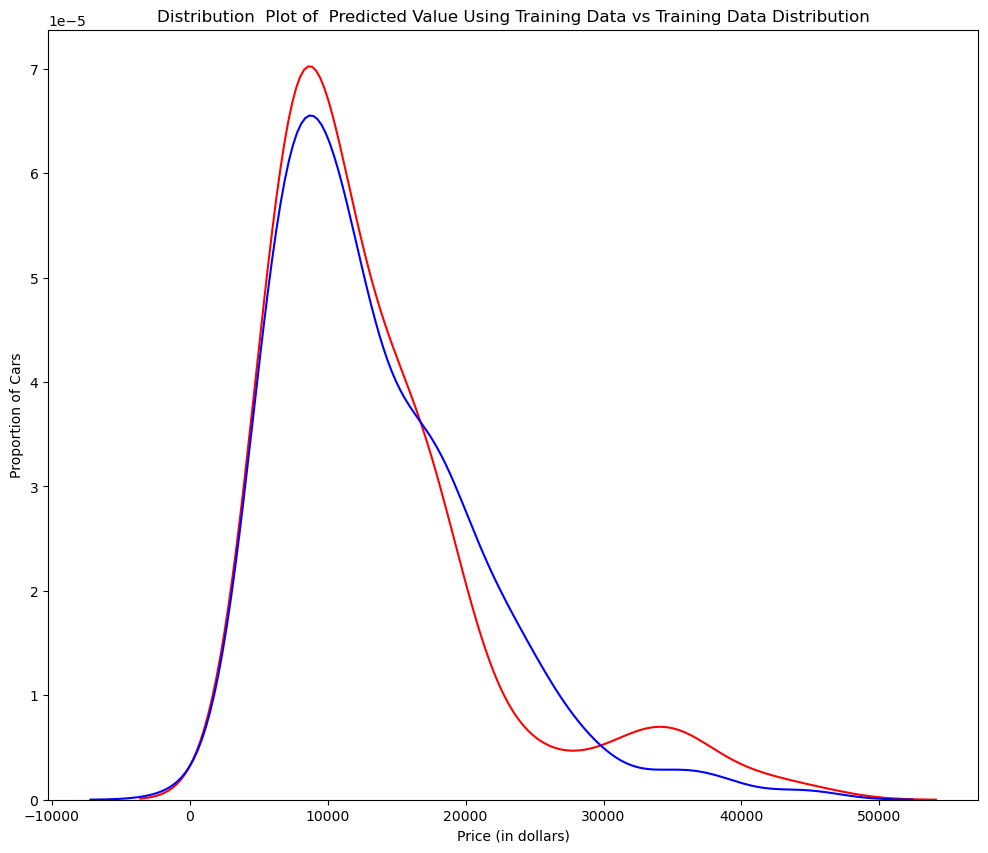

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns


Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (Train)", "Predicted Values (Train)", Title)

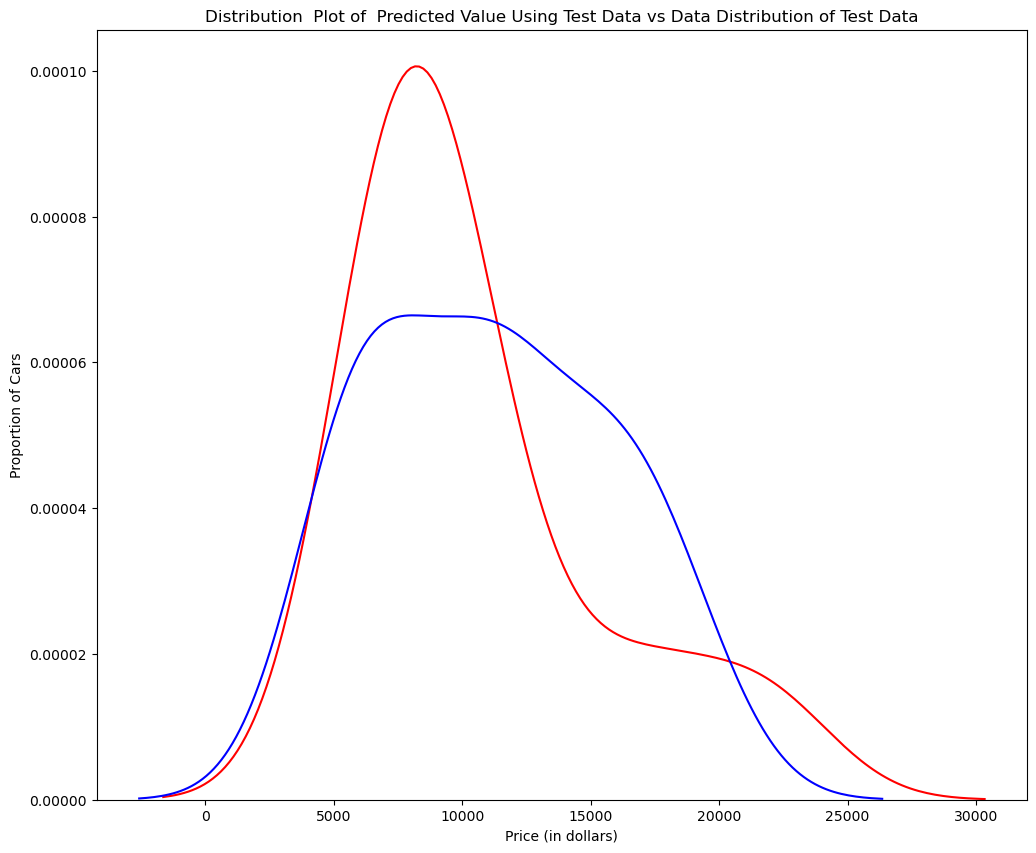

In [22]:
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)","Predicted Values (Test)",Title)

<p>Comparing Figure 1 and Figure 2, it is evident that the distribution of the test data in Figure 1 is much better at fitting the data. This difference in Figure 2 is apparent in the range of 5000 to 15,000. This is where the shape of the distribution is extremely different. Let's see if polynomial regression also exhibits a drop in the prediction accuracy when analysing the test dataset.</p>


### Overfitting
Overfitting occurs when the model fits the noise, but not the underlying process. Therefore, when testing your model using the test set, your model does not perform as well since it is modelling noise, not the underlying process that generated the relationship. Let's create a degree 5 polynomial model.


Let's use 55 percent of the data for training and the rest for testing:


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.45, random_state=0)

We will perform a degree 5 polynomial transformation on the feature <b>'horsepower'</b>. 


In [24]:
from sklearn.preprocessing import PolynomialFeatures

pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.fit_transform(x_test[['horsepower']])
pr

PolynomialFeatures(degree=5)

In [25]:
poly = LinearRegression()
poly.fit(x_train_pr, y_train)
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([ 6728.73877623,  7308.06173582, 12213.81078747, 18893.1290908 ,
       19995.81407813])

In [26]:
print("Predicted values:", yhat[0:4])
print("True values:", y_test[0:4].values)

Predicted values: [ 6728.73877623  7308.06173582 12213.81078747 18893.1290908 ]
True values: [ 6295. 10698. 13860. 13499.]


We will use the function "PollyPlot" that we defined at the beginning of the lab to display the training data, testing data, and the predicted function.


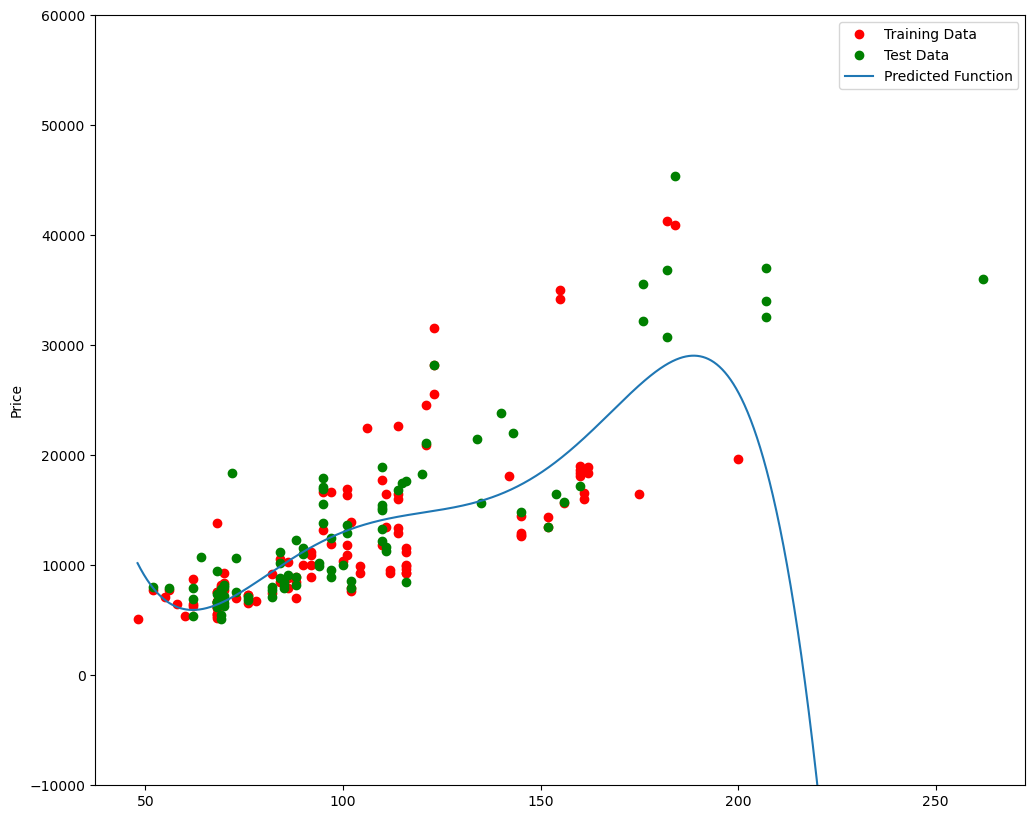

In [27]:
PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)

We see that the estimated function appears to track the data but around 200 horsepower, the function begins to diverge from the data points. 


In [28]:
poly.score(x_train_pr, y_train)

0.5567716902028981

 R^2 of the test data:


In [29]:
poly.score(x_test_pr, y_test)

-29.871621329672777

We see the R^2 for the training data is 0.5567 while the R^2 on the test data was -29.87.  The lower the R^2, the worse the model. A negative R^2 is a sign of overfitting.


Text(3, 0.75, 'Maximum R^2 ')

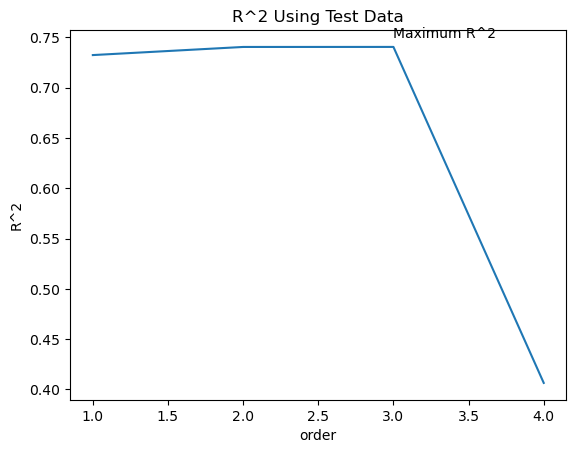

In [30]:
Rsqu_test = []

order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)
    
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    
    x_test_pr = pr.fit_transform(x_test[['horsepower']])    
    
    lr.fit(x_train_pr, y_train)
    
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2 ')    

In [31]:
def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train,y_test, poly, pr)

The following interface allows you to experiment with different polynomial orders and different amounts of data. 


In [32]:
pr1 = PolynomialFeatures(degree=2)
x_train_pr1 = pr1.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_test_pr1 = pr1.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_train_pr1.shape

(110, 15)

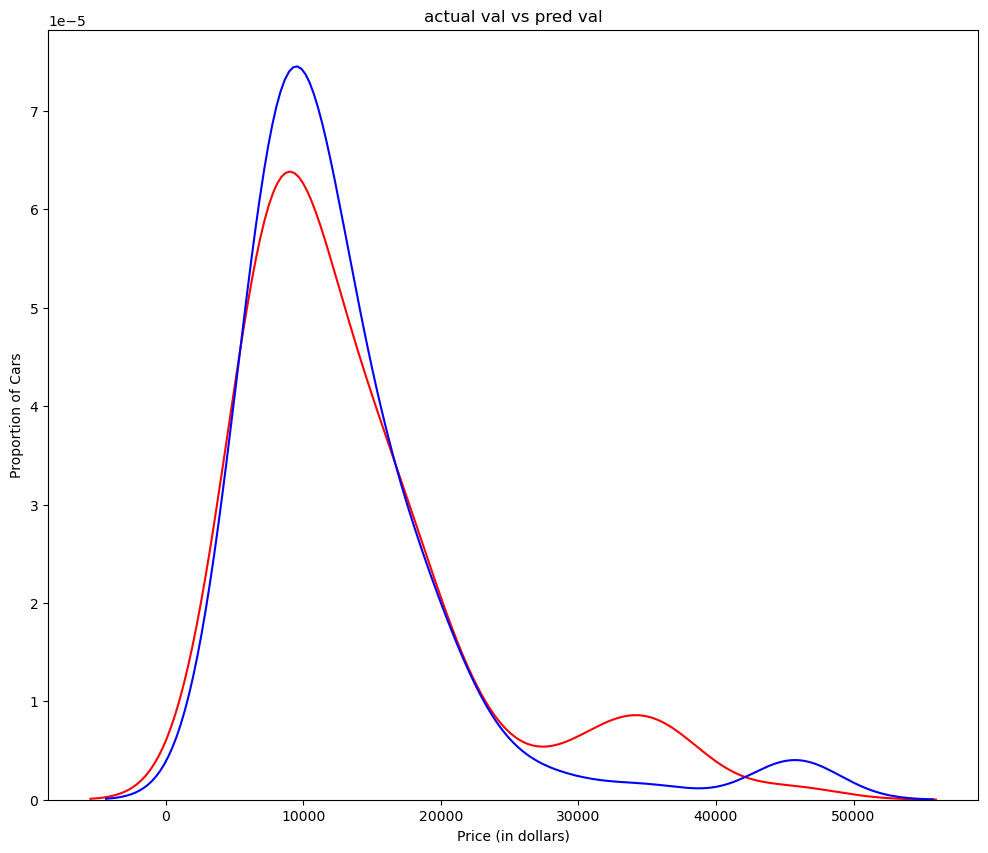

In [33]:
poly1 = LinearRegression().fit(x_train_pr1,y_train)
pred = poly1.predict(x_test_pr1)
DistributionPlot(y_test,pred,"actual value","predicted value","actual val vs pred val")

<h2 id="ref3">Part 3: Ridge Regression</h2> 


 Let's perform a degree two polynomial transformation on our data. 


In [34]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])
x_test_pr=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])

## 📘 What is Ridge Regression?

Ridge regression is a type of **regularized linear regression** that addresses some weaknesses of **ordinary least squares (OLS)** linear regression — especially **overfitting** and **multicollinearity** (when predictors are highly correlated).

### 📐 Ridge Regression Equation

Ridge minimizes the **cost function**:

$$
\text{Loss} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2
$$

Where:

* $y_i$: true value
* $\hat{y}_i$: predicted value
* $w_j$: model coefficients
* $\alpha$: regularization strength
* The second term $\alpha \sum w_j^2$ is the **L2 penalty**

> L2 penalty discourages large weights, helping to reduce model variance (overfitting) while keeping the model interpretable.

---

### ⚖️ Ridge vs Linear Regression

| Feature                    | Linear Regression                      | Ridge Regression                         |
| -------------------------- | -------------------------------------- | ---------------------------------------- |
| Regularization             | ❌ No                                   | ✅ Yes (L2 regularization)                |
| Overfitting Risk           | Higher (especially with many features) | Lower                                    |
| Multicollinearity Handling | Poor                                   | Better (shrinks correlated coefficients) |
| Penalty Term               | None                                   | $\alpha \sum w_j^2$                      |

---

### ⚙️ Common Parameters in `Ridge`

| Parameter                | Description                                                                        |
| ------------------------ | ---------------------------------------------------------------------------------- |
| `alpha`                  | Regularization strength (default = 1.0)                                            |
| `fit_intercept`          | Whether to fit the intercept (default = True)                                      |
| `normalize` (deprecated) | Used to normalize input variables                                                  |
| `solver`                 | Algorithm to use in optimization (`'auto'`, `'svd'`, `'cholesky'`, `'saga'`, etc.) |
| `max_iter`               | Maximum number of iterations (for solvers that use iterative optimization)         |
| `random_state`           | Seed for reproducibility (used with some solvers)                                  |

---

### 🔍 When to Use Ridge Regression

* You have **many correlated features**
* You're seeing **overfitting** with linear regression
* You want a **less complex model** that still generalizes well
* You want **control over model complexity** via `alpha`

---


In [35]:
from sklearn.linear_model import Ridge

RigeModel=Ridge(alpha=1)
RigeModel.fit(x_train_pr, y_train)

Ridge(alpha=1)

In [36]:
yhat = RigeModel.predict(x_test_pr)
print('predicted:', yhat[0:4])
print('test set :', y_test[0:4].values)

predicted: [ 6570.82441941  9636.24891471 20949.92322737 19403.60313255]
test set : [ 6295. 10698. 13860. 13499.]


#### 🧠 What's `alpha`?

* `alpha` controls the **strength of regularization**:

  * `alpha = 0` → equivalent to ordinary **Linear Regression**
  * Higher `alpha` values → **more regularization**, **simpler model**, less overfitting
  * Lower `alpha` values → **less regularization**, more flexible, but more prone to overfitting

In [37]:
Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0, 1000))

for alpha in Alpha:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    
    test_score = RigeModel.score(x_test_pr, y_test)
    train_score = RigeModel.score(x_train_pr, y_train)

    # Optional: print progress manually (slower)
    print(f"Alpha: {alpha}, Test Score: {test_score:.4f}, Train Score: {train_score:.4f}")
    
    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)

Alpha: 0, Test Score: 0.4710, Train Score: 0.8535
Alpha: 10, Test Score: 0.5419, Train Score: 0.8707
Alpha: 20, Test Score: 0.5452, Train Score: 0.8701
Alpha: 30, Test Score: 0.5468, Train Score: 0.8696
Alpha: 40, Test Score: 0.5475, Train Score: 0.8690
Alpha: 50, Test Score: 0.5478, Train Score: 0.8685
Alpha: 60, Test Score: 0.5479, Train Score: 0.8680
Alpha: 70, Test Score: 0.5477, Train Score: 0.8676
Alpha: 80, Test Score: 0.5475, Train Score: 0.8672
Alpha: 90, Test Score: 0.5472, Train Score: 0.8669
Alpha: 100, Test Score: 0.5469, Train Score: 0.8666
Alpha: 110, Test Score: 0.5465, Train Score: 0.8663
Alpha: 120, Test Score: 0.5462, Train Score: 0.8660
Alpha: 130, Test Score: 0.5459, Train Score: 0.8658
Alpha: 140, Test Score: 0.5455, Train Score: 0.8656
Alpha: 150, Test Score: 0.5452, Train Score: 0.8653
Alpha: 160, Test Score: 0.5449, Train Score: 0.8652
Alpha: 170, Test Score: 0.5446, Train Score: 0.8650
Alpha: 180, Test Score: 0.5443, Train Score: 0.8648
Alpha: 190, Test Score:

We can plot out the value of R^2 for different alphas: 


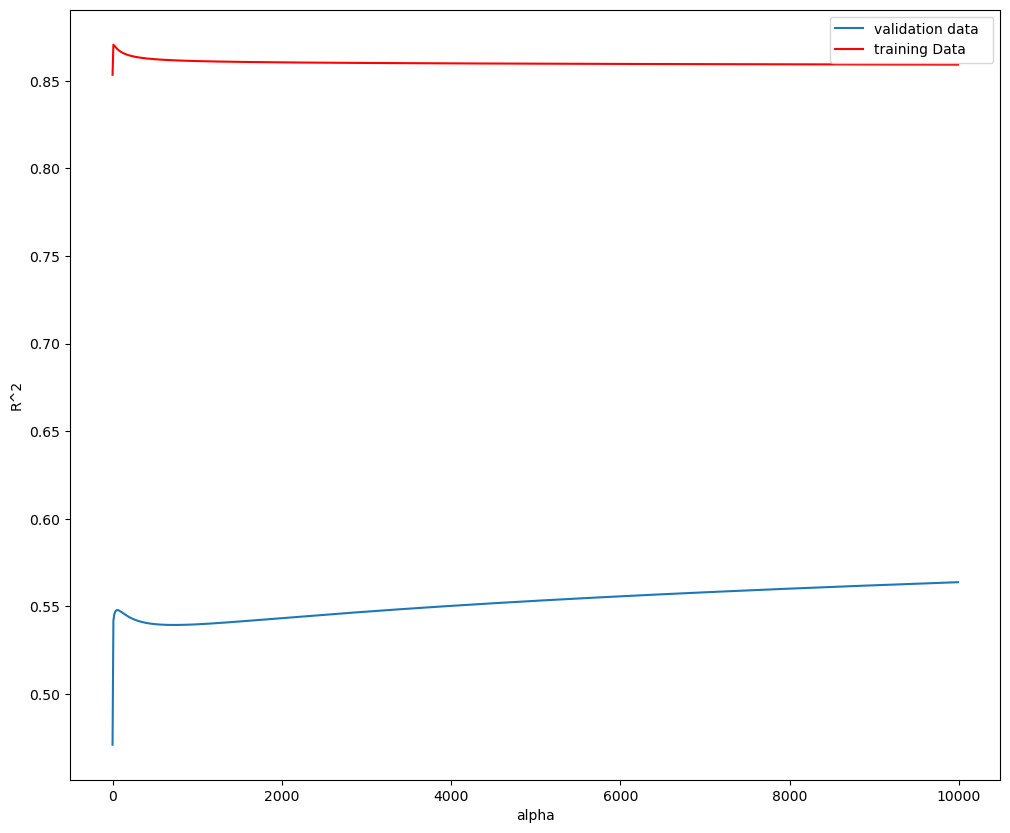

In [38]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

In [39]:
RigeModel = Ridge(alpha=10) 
RigeModel.fit(x_train_pr, y_train)
RigeModel.score(x_test_pr, y_test)

0.5418576440207269

<h2 id="ref4">Part 4: Grid Search</h2>


**`GridSearchCV`** is a tool from **scikit-learn** used for **hyperparameter tuning**.

It **automatically searches for the best combination of hyperparameters** for a given model by:

1. Trying **all combinations** of hyperparameters you specify (grid search),
2. Evaluating each combination using **cross-validation**, and
3. Returning the **best model** (based on the chosen scoring metric).

---
### ✅ How It Works (Step-by-Step)

1. You give it:

   * An **estimator** (like `Ridge()` or `RandomForestClassifier()`),
   * A **grid of hyperparameter values** to try,
   * Optionally: a **scoring metric** and cross-validation strategy.

2. It:

   * Trains the model on different combinations of hyperparameters,
   * Uses **cross-validation** to estimate model performance,
   * Identifies the **best combination**.

3. You can then:

   * Access the best model (`.best_estimator_`)
   * See the best parameters (`.best_params_`)
   * Review performance scores for all combinations (`.cv_results_`)

---
### 📄 Parameters of `GridSearchCV`

| Parameter            | Description                                                                |
| -------------------- | -------------------------------------------------------------------------- |
| `estimator`          | The model you want to tune (e.g. `Ridge()`, `SVC()`)                       |
| `param_grid`         | Dictionary or list of dictionaries with hyperparameters and values to try  |
| `scoring`            | Metric to evaluate (e.g. `'accuracy'`, `'r2'`, `'neg_mean_squared_error'`) |
| `cv`                 | Cross-validation strategy (e.g. `5`, `KFold`, `StratifiedKFold`)           |
| `n_jobs`             | Number of parallel jobs (`-1` uses all CPUs)                               |
| `verbose`            | Logging level (`0` = silent, `1+` = more messages)                         |
| `return_train_score` | If `True`, also return train scores in `.cv_results_`                      |

---

### 📦 Outputs / Attributes

| Attribute          | Description                                 |
| ------------------ | ------------------------------------------- |
| `.best_params_`    | Best hyperparameters combination            |
| `.best_score_`     | Best average cross-validation score         |
| `.best_estimator_` | Estimator with best params, already fitted  |
| `.cv_results_`     | Detailed results for each param combination |

---

In [40]:
from sklearn.model_selection import GridSearchCV

parameters1= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
parameters1

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]

In [41]:
RR=Ridge()
RR

Ridge()

In [42]:
Grid1 = GridSearchCV(RR, parameters1,cv=4)
Grid1.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])

The object finds the best parameter values on the validation data. We can obtain the estimator with the best parameters and assign it to the variable BestRR as follows:


In [43]:
BestRR=Grid1.best_estimator_
BestRR

Ridge(alpha=10000)

 We now test our model on the test data:


In [44]:
BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test)

0.8411649831036149

## Good Job!

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>